# Téléchargement et nettoyage des données DVF

Télécharge, nettoie et exporte des fichiers DVF (format txt.zip, séparateur '|').

DVF : Demande de valeur foncières


Le script:
 - télécharge chaque zip,
 - lit le .txt interne en chunks pour limiter la mémoire,
 - conserve un jeu de colonnes "utiles",
 - applique conversions/normalisations,
 - sauvegarde un parquet par année et un fichier combiné merged.parquet.

## 1. Import

In [ ]:
import os
import sys
import tempfile
import zipfile
import requests
from io import BytesIO, TextIOWrapper
import pandas as pd
import numpy as np
import fastparquet as fp
from fastparquet import write as fp_write
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_gathering import process_zip_url, merge_years

# 2. Format de données

Les variables :

 - EXPECTED_COLUMNS : Les colonnes présentes dans le .txt du site gov.fr
 - KEEP : Les colones à garder
 - RENAME_MAP : la correspondance des noms de colonnes KEEP avec des noms plus propres

In [ ]:
EXPECTED_COLUMNS = [
    "Identifiant de document","Reference document",
    "1 Articles CGI","2 Articles CGI","3 Articles CGI","4 Articles CGI","5 Articles CGI",
    "No disposition","Date mutation","Nature mutation","Valeur fonciere",
    "No voie","B/T/Q","Type de voie","Code voie","Voie","Code postal","Commune",
    "Code departement","Code commune","Prefixe de section","Section","No plan",
    "No Volume","1er lot","Surface Carrez du 1er lot","2eme lot","Surface Carrez du 2eme lot",
    "3eme lot","Surface Carrez du 3eme lot","4eme lot","Surface Carrez du 4eme lot",
    "5eme lot","Surface Carrez du 5eme lot","Nombre de lots","Code type local","Type local",
    "Identifiant local","Surface reelle bati","Nombre pieces principales","Nature culture",
    "Nature culture speciale","Surface terrain"
]

## 3. Test d'exécution

In [ ]:
urls = ["https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234902/valeursfoncieres-2025-s1.txt.zip"
        ,"https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234857/valeursfoncieres-2024.txt.zip"
        ,"https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234851/valeursfoncieres-2023.txt.zip"
        ,"https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234844/valeursfoncieres-2022.txt.zip"
        ,"https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234836/valeursfoncieres-2021.txt.zip"
        ,"http://data.cquest.org/dgfip_dvf/202104/valeursfoncieres-2020.txt"
        ,"http://data.cquest.org/dgfip_dvf/202104/valeursfoncieres-2019.txt"
        ,"http://data.cquest.org/dgfip_dvf/202104/valeursfoncieres-2018.txt"
        ,"http://data.cquest.org/dgfip_dvf/202104/valeursfoncieres-2017.txt"
        ,"http://data.cquest.org/dgfip_dvf/202104/valeursfoncieres-2016.txt"
        ,"http://data.cquest.org/dgfip_dvf/201904/valeursfoncieres-2015.txt"
        ,"http://data.cquest.org/dgfip_dvf/201904/valeursfoncieres-2014.txt"
        ]

years = ["2025","2024","2023","2022","2021","2020","2019","2018","2017","2016","2015","2014"]

outdir = "./data/processed"

chunksize = 200000

In [11]:
os.makedirs(outdir, exist_ok=True)
parquet_paths = []
for url, year in zip(urls, years):
    p = process_zip_url(url, year, outdir, chunksize=chunksize)
    if p:
        parquet_paths.append(p)

[2025] téléchargement : https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234902/valeursfoncieres-2025-s1.txt.zip
[2025] ouverture (zip ou fichier brut)...
[2025] lecture par chunks...
[2025] Lecture chunk 6...
[2025] 421455 lignes sauvegardées → ./data/per_year/dvf_clean_2025.parquet
[2024] téléchargement : https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234857/valeursfoncieres-2024.txt.zip
[2024] ouverture (zip ou fichier brut)...
[2024] lecture par chunks...
[2024] Lecture chunk 17...
[2024] 1026513 lignes sauvegardées → ./data/per_year/dvf_clean_2024.parquet
[2023] téléchargement : https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234851/valeursfoncieres-2023.txt.zip
[2023] ouverture (zip ou fichier brut)...
[2023] lecture par chunks...
[2023] Lecture chunk 19...
[2023] 1143810 lignes sauvegardées → ./data/per_year/dvf_clean_2023.parquet
[2022] téléchargement : https://static.data.gouv.fr/resources/d

Fusion de toutes les années dans un unique fichier parquet.

In [ ]:
if parquet_paths:
    merged = os.path.join(outdir, "dvf_merged_since2014.parquet")
    merge_years(parquet_paths, merged)
    print("All done.")
else:
    print("Aucun fichier traité.")

lecture: ./data/per_year/dvf_clean_2025.parquet
lecture: ./data/per_year/dvf_clean_2024.parquet
lecture: ./data/per_year/dvf_clean_2023.parquet
lecture: ./data/per_year/dvf_clean_2022.parquet
lecture: ./data/per_year/dvf_clean_2021.parquet
lecture: ./data/per_year/dvf_clean_2020.parquet
lecture: ./data/per_year/dvf_clean_2019.parquet
lecture: ./data/per_year/dvf_clean_2018.parquet
lecture: ./data/per_year/dvf_clean_2017.parquet
lecture: ./data/per_year/dvf_clean_2016.parquet
lecture: ./data/per_year/dvf_clean_2015.parquet
lecture: ./data/per_year/dvf_clean_2014.parquet
Merged saved to ./data/dvf_merged_since2014.parquet
All done.


## 4. Statistiques

Quelques statistiques sur les données récupérées et nettoyées sur les 5 dernières années.

In [13]:
merged = os.path.join(outdir, "dvf_merged_since2014.parquet")
df = fp.ParquetFile(merged).to_pandas()

print("Colonnes : ", df.columns)

print("Nombre de lignes :", len(df))

nb_lignes_completes = df.dropna().shape[0]
print("Nombre de lignes complètes :", nb_lignes_completes)

print("\n", df.describe().drop(index=['25%', '50%', '75%'], errors='ignore'))

print("\n Un extrait : \n", df.head())

Colonnes :  Index(['date_mutation', 'valeur_fonciere', 'type_local', 'surface_reelle_bati',
       'nb_pieces_principales', 'code_postal', 'commune', 'code_departement',
       'code_commune', 'code_voie', 'nombre_de_lots', 'surface_m2', 'prix_m2',
       'source_year'],
      dtype='object')
Nombre de lignes : 13393529
Nombre de lignes complètes : 13389853

                        date_mutation  valeur_fonciere  surface_reelle_bati  \
count                       13393529     1.339353e+07         1.339353e+07   
mean   2019-11-19 09:33:22.214143232     2.631923e+05         1.081310e+02   
min              2014-01-01 00:00:00     2.000000e+02         4.000000e+00   
max              2025-06-30 00:00:00     4.450000e+08         3.129620e+05   
std                              NaN     8.491028e+05         5.030782e+02   

       nb_pieces_principales    surface_m2       prix_m2   source_year  
count           1.339353e+07  1.339353e+07  1.339353e+07  1.339353e+07  
mean            3.24568

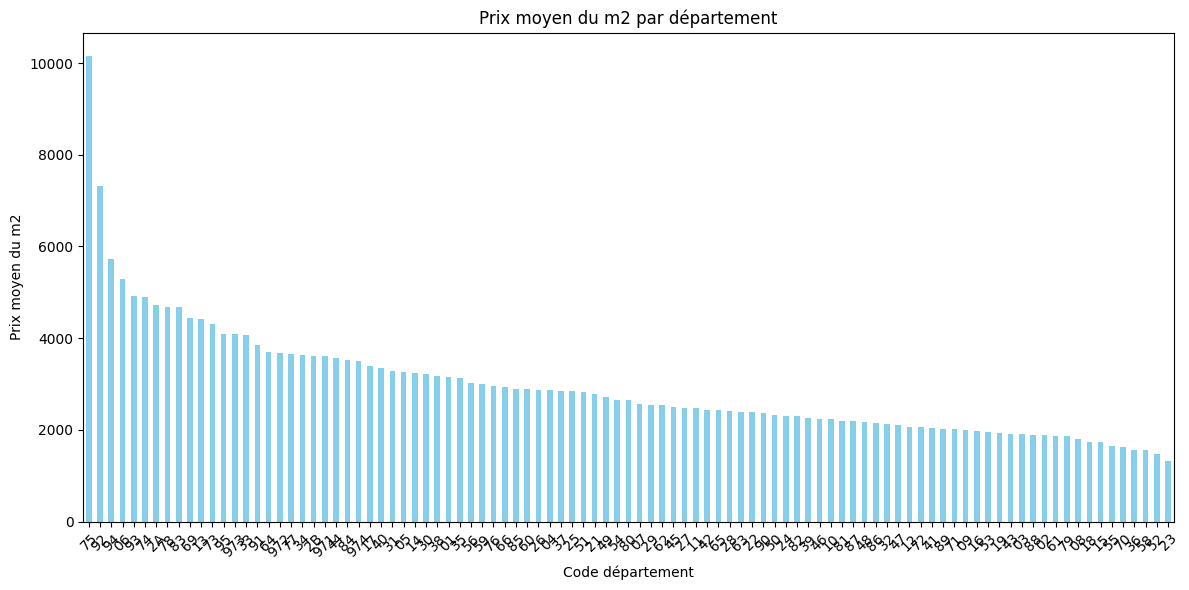

In [ ]:
# Calcul du prix moyen par département
df_clean = df.dropna(subset=['prix_m2', 'code_departement'])
prix_moyen_dept = df_clean.groupby('code_departement')['prix_m2'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
prix_moyen_dept.plot(kind='bar', color='skyblue')
plt.title("Prix moyen du m2 par département")
plt.xlabel("Code département")
plt.ylabel("Prix moyen du m2")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()